## 1. Setup Awal
Mount Google Drive, install & import library, set random seed, dan aktifkan **mixed precision** (FP16) agar training lebih cepat dan hemat VRAM di GPU T4.

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Install & Import Library

!pip install -q tensorflow opencv-python scikit-learn seaborn pandas matplotlib

import os
import time
import shutil
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, mixed_precision
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Seed & Mixed Precision

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 3

CLASS_NAMES = ['0_Recyclable', '1_Electronic', '2_Organic']
DISPLAY_NAMES = ['Recyclable', 'Electronic', 'Organic']
LABEL_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

mixed_precision.set_global_policy('mixed_float16')
print('Compute dtype kebijakan mixed precision:', mixed_precision.global_policy().compute_dtype)


Compute dtype kebijakan mixed precision: float16


## 2. Menyalin Dataset ke Disk Lokal Colab


In [ ]:

# Path Dataset di Google Drive

# DATASET_ROOT
DATASET_ROOT = '/content/drive/MyDrive/2026/BDC2026'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
TEST_DIR = os.path.join(DATASET_ROOT, 'test')

# OUTPUT_ROOT
OUTPUT_ROOT = '/content/drive/MyDrive/BDC2026_2'
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("DATASET_ROOT (punya panitia, read-only) :", DATASET_ROOT)
print("Ada?                                    :", os.path.exists(DATASET_ROOT))
print("Kelas train                             :", os.listdir(TRAIN_DIR) if os.path.exists(TRAIN_DIR) else "TIDAK DITEMUKAN")
print("OUTPUT_ROOT (punya sendiri, untuk backup):", OUTPUT_ROOT)


DATASET_ROOT (punya panitia, read-only) : /content/drive/MyDrive/2026/BDC2026
Ada?                                    : True
Kelas train                             : ['0_Recyclable', '1_Electronic', '2_Organic']
OUTPUT_ROOT (punya sendiri, untuk backup): /content/drive/MyDrive/BDC2026_2


In [ ]:
# Salin Dataset ke Disk Lokal

from concurrent.futures import ThreadPoolExecutor, as_completed

def copy_tree_parallel(src_dir, dst_dir, max_workers=32):
    '''Menyalin seluruh isi src_dir -> dst_dir dengan banyak thread sekaligus.
    Cocok untuk banyak file kecil dari Google Drive (I/O-bound).'''
    os.makedirs(dst_dir, exist_ok=True)
    tasks = []
    for root, dirs, files in os.walk(src_dir):
        rel = os.path.relpath(root, src_dir)
        target_root = os.path.join(dst_dir, rel) if rel != '.' else dst_dir
        os.makedirs(target_root, exist_ok=True)
        for f in files:
            tasks.append((os.path.join(root, f), os.path.join(target_root, f)))

    def _copy(pair):
        s, d = pair
        if not os.path.exists(d):
            shutil.copy2(s, d)
        return d

    done = 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_copy, t) for t in tasks]
        for _ in as_completed(futures):
            done += 1
            if done % 3000 == 0:
                print(f"  ... {done}/{len(tasks)} file disalin")
    print(f"Selesai: {done}/{len(tasks)} file -> {dst_dir}")


LOCAL_ROOT = '/content/BDC2026_local'
LOCAL_TRAIN = os.path.join(LOCAL_ROOT, 'train')
LOCAL_TEST = os.path.join(LOCAL_ROOT, 'test')

t0 = time.time()
if not os.path.exists(LOCAL_TRAIN):
    print("Menyalin data TRAIN dari Google Drive ke disk lokal Colab...")
    copy_tree_parallel(TRAIN_DIR, LOCAL_TRAIN)
else:
    print("Data TRAIN lokal sudah ada, lewati proses penyalinan.")

if not os.path.exists(LOCAL_TEST):
    print("Menyalin data TEST dari Google Drive ke disk lokal Colab...")
    copy_tree_parallel(TEST_DIR, LOCAL_TEST)
else:
    print("Data TEST lokal sudah ada, lewati proses penyalinan.")
print(f"Total waktu penyalinan: {time.time()-t0:.1f} detik")


Menyalin data TRAIN dari Google Drive ke disk lokal Colab...
  ... 3000/26527 file disalin
  ... 6000/26527 file disalin
  ... 9000/26527 file disalin
  ... 12000/26527 file disalin
  ... 15000/26527 file disalin
  ... 18000/26527 file disalin
  ... 21000/26527 file disalin
  ... 24000/26527 file disalin
Selesai: 26527/26527 file -> /content/BDC2026_local/train
Menyalin data TEST dari Google Drive ke disk lokal Colab...
Selesai: 1458/1458 file -> /content/BDC2026_local/test
Total waktu penyalinan: 418.2 detik


## 3. Eksplorasi Dataset
Cek jumlah gambar per kategori dan lihat beberapa contoh gambar untuk memastikan data sudah tersalin dengan benar.

In [ ]:
# Cek Jumlah Gambar per Kategori

print("Jumlah gambar per kategori (train):")
total_train = 0
for cat in CLASS_NAMES:
    cat_dir = os.path.join(LOCAL_TRAIN, cat)
    n = len(os.listdir(cat_dir))
    total_train += n
    print(f"  {cat:15s}: {n} gambar")
print(f"Total train: {total_train} gambar")

n_test = len(os.listdir(LOCAL_TEST))
print(f"Total test : {n_test} gambar")


Jumlah gambar per kategori (train):
  0_Recyclable   : 9999 gambar
  1_Electronic   : 3961 gambar
  2_Organic      : 12567 gambar
Total train: 26527 gambar
Total test : 1458 gambar


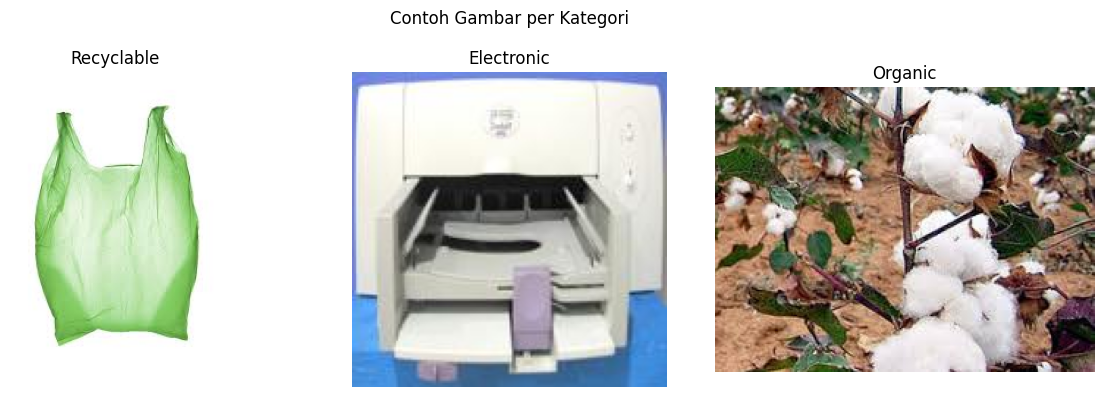

In [ ]:
# Lihat Beberapa Contoh Gambar per Kategori

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cat in enumerate(CLASS_NAMES):
    cat_dir = os.path.join(LOCAL_TRAIN, cat)
    sample_file = random.choice(os.listdir(cat_dir))
    img = cv2.cvtColor(cv2.imread(os.path.join(cat_dir, sample_file)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(DISPLAY_NAMES[i])
    axes[i].axis('off')
plt.suptitle('Contoh Gambar per Kategori')
plt.tight_layout()
plt.show()


## 4. Split Data Train / Validation
Kumpulkan semua path gambar train, lalu split stratified 85/15 dengan `random_state` tetap supaya hasilnya konsisten dan bisa direproduksi.

In [ ]:
# Kumpulkan Path Gambar Train + Label

train_paths, train_labels = [], []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(LOCAL_TRAIN, cls)
    for fname in os.listdir(cls_dir):
        train_paths.append(os.path.join(cls_dir, fname))
        train_labels.append(LABEL_TO_IDX[cls])

train_paths = np.array(train_paths)
train_labels = np.array(train_labels)
print('Total gambar train ditemukan:', len(train_paths))

X_train, X_val, y_train, y_val = train_test_split(
    train_paths, train_labels,
    test_size=0.15, random_state=SEED, stratify=train_labels
)
print('Train      :', len(X_train))
print('Validation :', len(X_val))


Total gambar train ditemukan: 26527
Train      : 22547
Validation : 3980


## 5. Preprocessing AGBF (Adaptive Gaussian Bilateral Filter)
AGBF mengombinasikan Gaussian blur (meredam noise) dan bilateral filter (mempertahankan tepi objek), dengan bobot campuran yang adaptif berdasarkan besarnya gradien tepi (area bertekstur/edge kuat akan lebih banyak memakai bilateral filter, area halus lebih banyak Gaussian blur).

In [ ]:
# Fungsi AGBF

def agbf_filter(img_uint8, d=9, sigma_color_base=40.0, sigma_space=75.0, gaussian_ksize=5):
    img = img_uint8.astype(np.float32)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # Variansi lokal -> menyesuaikan sigmaColor terhadap tingkat noise/tekstur gambar
    local_mean = cv2.blur(gray.astype(np.float32), (7, 7))
    local_sq_mean = cv2.blur((gray.astype(np.float32)) ** 2, (7, 7))
    local_var = np.clip(local_sq_mean - local_mean ** 2, 0, None)
    noise_scale = float(np.clip(local_var.mean() / 500.0, 0.3, 3.0))
    sigma_color = sigma_color_base * noise_scale

    gaussian = cv2.GaussianBlur(img_uint8, (gaussian_ksize, gaussian_ksize), 0).astype(np.float32)
    bilateral = cv2.bilateralFilter(img_uint8, d, sigma_color, sigma_space).astype(np.float32)

    # Peta gradien tepi -> menentukan proporsi campuran gaussian vs bilateral per piksel
    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x ** 2 + grad_y ** 2)
    grad_mag = grad_mag / (grad_mag.max() + 1e-6)
    alpha = grad_mag[..., None]  # HxWx1, broadcast ke channel warna

    blended = alpha * bilateral + (1.0 - alpha) * gaussian
    return np.clip(blended, 0, 255).astype(np.uint8)


def tf_agbf(image):
    '''Pembungkus tf.numpy_function supaya agbf_filter bisa dipakai di dalam tf.data.'''
    def _apply(img):
        return agbf_filter(img)
    filtered = tf.numpy_function(_apply, [image], tf.uint8)
    filtered.set_shape(image.shape)
    return filtered


## 6. Pipeline `tf.data` dengan Caching

Ini adalah optimasi efisiensi kedua. AGBF (khususnya bilateral filter) adalah operasi **CPU-berat**. Kalau dihitung ulang di setiap epoch, ini menjadi bottleneck utama.

Trik yang dipakai di sini:
- Pipeline dipecah menjadi **2 tahap**: (1) decode + resize + AGBF (deterministik, berat), (2) augmentasi acak + normalisasi (ringan, harus tetap acak tiap epoch).
- `.cache()` dipasang **setelah tahap 1** (AGBF) dan **sebelum tahap 2** (augmentasi). Jadi AGBF cuma dihitung sekali per gambar (di epoch pertama), lalu untuk epoch-epoch berikutnya tinggal dibaca dari cache — sementara augmentasi tetap acak setiap epoch karena berada di luar cache.
- Cache disimpan sebagai file di disk lokal (`/content/cache_*`) karena datasetnya besar (puluhan ribu gambar) dan mungkin tidak muat semua di RAM.

In [ ]:
# Fungsi Preprocessing Deterministik (di-cache) & Augmentasi (tidak di-cache)

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_agbf(path, label):
    '''Tahap berat & deterministik: decode -> resize -> AGBF. Akan di-cache.'''
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method='bilinear')
    img = tf.cast(img, tf.uint8)
    img = tf_agbf(img)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label


def augment_and_normalize(img, label, augment=False):
    '''Tahap ringan & acak: augmentasi -> normalisasi ResNet50. TIDAK di-cache.'''
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, label


def make_dataset(paths, labels, batch_size=BATCH_SIZE, shuffle=False, augment=False, cache_path=None):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess_agbf, num_parallel_calls=AUTOTUNE)

    if cache_path is not None:
        ds = ds.cache(cache_path)

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 4096), seed=SEED)

    ds = ds.map(lambda img, lab: augment_and_normalize(img, lab, augment=augment),
                num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


CACHE_DIR = '/content/tfcache'
os.makedirs(CACHE_DIR, exist_ok=True)

train_ds = make_dataset(X_train, y_train, shuffle=True, augment=True,
                         cache_path=os.path.join(CACHE_DIR, 'train'))
val_ds = make_dataset(X_val, y_val, shuffle=False, augment=False,
                       cache_path=os.path.join(CACHE_DIR, 'val'))

print('Pipeline tf.data siap (dengan caching aktif).')


Pipeline tf.data siap (dengan caching aktif).


## 7. Arsitektur Model — ResNet50 + AGBF

- Backbone `ResNet50` (ImageNet weights), input 224x224x3
- Head: `GlobalAveragePooling2D -> Dropout(0.3) -> Dense(256, relu) -> Dropout(0.3) -> Dense(3, softmax)`
- Output layer dipaksa `dtype='float32'` agar softmax tetap stabil secara numerik saat memakai mixed precision (FP16)
- Fungsi `build_model` mendukung mode freeze (`unfreeze_from=None`) maupun fine-tuning (`unfreeze_from=<index_layer>`)

In [ ]:
# Bangun Model

def build_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE, unfreeze_from=None):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    base.trainable = unfreeze_from is not None

    if unfreeze_from is not None:
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=(unfreeze_from is not None))
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs)
    return model, base


model, backbone = build_model(unfreeze_from=None)
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 8. Callbacks & Mekanisme Resume Training

Checkpoint disimpan **langsung ke Google Drive** (bukan hanya ke disk lokal Colab yang sementara), sehingga kalau runtime terputus (idle timeout / limit GPU tercapai), kita bisa mount ulang Drive di sesi baru dan **melanjutkan training dari epoch terakhir** tanpa mengulang dari nol.

- `ModelCheckpoint` menyimpan model **terbaik** (val_loss terendah) per fase.
- `CSVLogger` (mode `append=True`) mencatat riwayat training ke Drive, sehingga log tidak hilang walau sesi berpindah.
- `EarlyStopping` & `ReduceLROnPlateau` sesuai rekomendasi tambahan, membantu konvergensi lebih cepat dan mengurangi risiko overfitting.

In [ ]:
# STEP 12: Path Checkpoint di Drive + Fungsi Callback

CKPT_DIR = os.path.join(OUTPUT_ROOT, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

CKPT_HEAD = os.path.join(CKPT_DIR, 'best_model_head.keras')
CKPT_FINETUNE = os.path.join(CKPT_DIR, 'best_model_finetuned.keras')
LOG_HEAD = os.path.join(CKPT_DIR, 'history_head.csv')
LOG_FINETUNE = os.path.join(CKPT_DIR, 'history_finetune.csv')


def make_callbacks(ckpt_path, log_path, patience_es=6, patience_rlrop=3):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=patience_es,
                                 restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                     patience=patience_rlrop, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss',
                                   save_best_only=True, verbose=1),
        callbacks.CSVLogger(log_path, append=True),
    ]


print('Checkpoint & log akan disimpan di:', CKPT_DIR)
print('  ->', CKPT_HEAD)
print('  ->', CKPT_FINETUNE)


Checkpoint & log akan disimpan di: /content/drive/MyDrive/BDC2026_2/checkpoints
  -> /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_head.keras
  -> /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_finetuned.keras


## 9. Training Fase 1 — Backbone Freeze (Transfer Learning Awal)


In [ ]:
# Compile & Training Fase 1

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

EPOCHS_HEAD = 15
initial_epoch_head = 0

# kalau checkpoint fase 1 sudah ada, lanjutkan dari sana
if os.path.exists(CKPT_HEAD):
    print('Checkpoint fase 1 ditemukan, memuat bobot dan melanjutkan training...')
    model.load_weights(CKPT_HEAD)
    if os.path.exists(LOG_HEAD):
        initial_epoch_head = len(pd.read_csv(LOG_HEAD))
        print(f'Melanjutkan dari epoch ke-{initial_epoch_head}')

t0 = time.time()
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    initial_epoch=initial_epoch_head,
    callbacks=make_callbacks(CKPT_HEAD, LOG_HEAD),
)
train_time_head = time.time() - t0
print(f'\\nWaktu training Fase 1: {train_time_head:.1f} detik')


Epoch 1/15
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 934ms/step - accuracy: 0.8606 - loss: 0.3897
Epoch 1: val_loss improved from None to 0.17114, saving model to /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_head.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_head.keras
353/353 ━━━━━━━━━━━━━━━━━━━━ 499s 1s/step - accuracy: 0.8983 - loss: 0.2801 - val_accuracy: 0.9384 - val_loss: 0.1711 - learning_rate: 0.0010
Epoch 2/15
352/353 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9297 - loss: 0.1931
Epoch 2: val_loss improved from 0.17114 to 0.15270, saving model to /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_head.keras

Epoch 2: finished saving model to /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_head.keras
353/353 ━━━━━━━━━━━━━━━━━━━━ 74s 202ms/step - accuracy: 0.9287 - loss: 0.1937 - val_accuracy: 0.9490 - val_loss: 0.1527 - learning_rate: 0.0010
Epoch 3/15
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0

## 10. Training Fase 2 — Fine-Tuning Sebagian Layer ResNet50

Unfreeze layer dari index 143 ke atas (kira-kira blok residual terakhir, `conv5_block`), lalu lanjutkan training dengan learning rate lebih kecil. Sama seperti fase 1, sel ini bisa dijalankan ulang dengan aman jika sesi sebelumnya terputus.

In [ ]:
# Unfreeze Layer + Compile Ulang + Training Fase 2

UNFREEZE_FROM = 160

for i, layer in enumerate(backbone.layers):
    layer.trainable = i >= UNFREEZE_FROM

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

EPOCHS_FINETUNE = 10
initial_epoch_finetune = 0

if os.path.exists(CKPT_FINETUNE):
    print('Checkpoint fase 2 ditemukan, memuat bobot dan melanjutkan training...')
    model.load_weights(CKPT_FINETUNE)
    if os.path.exists(LOG_FINETUNE):
        initial_epoch_finetune = len(pd.read_csv(LOG_FINETUNE))
        print(f'Melanjutkan dari epoch ke-{initial_epoch_finetune}')

t0 = time.time()
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    initial_epoch=initial_epoch_finetune,
    callbacks=make_callbacks(CKPT_FINETUNE, LOG_FINETUNE),
)
train_time_finetune = time.time() - t0
print(f'\\nWaktu training Fase 2: {train_time_finetune:.1f} detik')


Epoch 1/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9731 - loss: 0.0714
Epoch 1: val_loss improved from None to 0.13226, saving model to /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_finetuned.keras
353/353 ━━━━━━━━━━━━━━━━━━━━ 115s 251ms/step - accuracy: 0.9737 - loss: 0.0699 - val_accuracy: 0.9573 - val_loss: 0.1323 - learning_rate: 1.0000e-05
Epoch 2/10
352/353 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9779 - loss: 0.0626
Epoch 2: val_loss did not improve from 0.13226
353/353 ━━━━━━━━━━━━━━━━━━━━ 66s 182ms/step - accuracy: 0.9783 - loss: 0.0622 - val_accuracy: 0.9563 - val_loss: 0.1325 - learning_rate: 1.0000e-05
Epoch 3/10
352/353 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9800 - loss: 0.0529
Epoch 3: val_loss improved from 0.13226 to 0.13054, saving model to /content/drive/MyDrive/BDC2026_2/checkpoints/best_model_finetuned.keras

Epoch 3

## 11. Evaluasi Model pada Data Validasi
Muat model terbaik hasil fine-tuning, lalu hitung accuracy, precision, recall, F1-score (weighted), classification report per kelas, dan confusion matrix.

In [ ]:
# Evaluasi pada Data Validasi

from tensorflow.keras.models import load_model

best_model = load_model(CKPT_FINETUNE)

val_loss, val_accuracy = best_model.evaluate(val_ds, verbose=1)

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("=" * 50)
print("HASIL EVALUASI PADA DATA VALIDASI")
print("=" * 50)
print(f"Jumlah data validasi : {len(y_true)}")
print(f"Validation Loss      : {val_loss:.4f}")
print(f"Accuracy             : {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision (weighted) : {prec:.4f}")
print(f"Recall (weighted)    : {rec:.4f}")
print(f"F1-Score (weighted)  : {f1:.4f}")
print()
report_text = classification_report(y_true, y_pred, target_names=DISPLAY_NAMES)
print(report_text)

# Backup ke Google Drive (supaya tidak hilang kalau runtime terputus)
report_path = os.path.join(CKPT_DIR, 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write(report_text)
print('Classification report tersimpan di Drive:', report_path)


63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.9578 - loss: 0.1305
HASIL EVALUASI PADA DATA VALIDASI
Jumlah data validasi : 3980
Validation Loss      : 0.1305
Accuracy             : 0.9578 (95.78%)
Precision (weighted) : 0.9578
Recall (weighted)    : 0.9578
F1-Score (weighted)  : 0.9578

              precision    recall  f1-score   support

  Recyclable       0.94      0.95      0.95      1500
  Electronic       0.97      0.98      0.97       594
     Organic       0.96      0.96      0.96      1886

    accuracy                           0.96      3980
   macro avg       0.96      0.96      0.96      3980
weighted avg       0.96      0.96      0.96      3980

Classification report tersimpan di Drive: /content/drive/MyDrive/BDC2026_2/checkpoints/classification_report.txt


Confusion matrix tersimpan di Drive: /content/drive/MyDrive/BDC2026_2/checkpoints/confusion_matrix.png


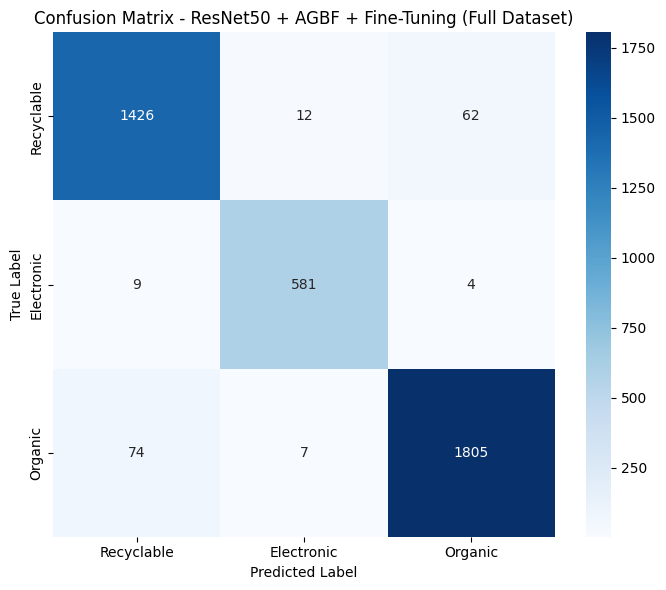

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES)
plt.title('Confusion Matrix - ResNet50 + AGBF + Fine-Tuning (Full Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

# Backup ke Google Drive
cm_path = os.path.join(CKPT_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=200, bbox_inches='tight')
print('Confusion matrix tersimpan di Drive:', cm_path)

plt.show()


## 12. Kurva Training (Accuracy & Loss, Fase 1 + Fase 2 Digabung)
Menyambungkan riwayat training Fase 1 (backbone freeze) dengan Fase 2 (fine-tuning) dalam satu grafik, dengan garis putus-putus penanda titik mulai fine-tuning.

Grafik kurva training tersimpan di Drive: /content/drive/MyDrive/BDC2026_2/checkpoints/training_history.png


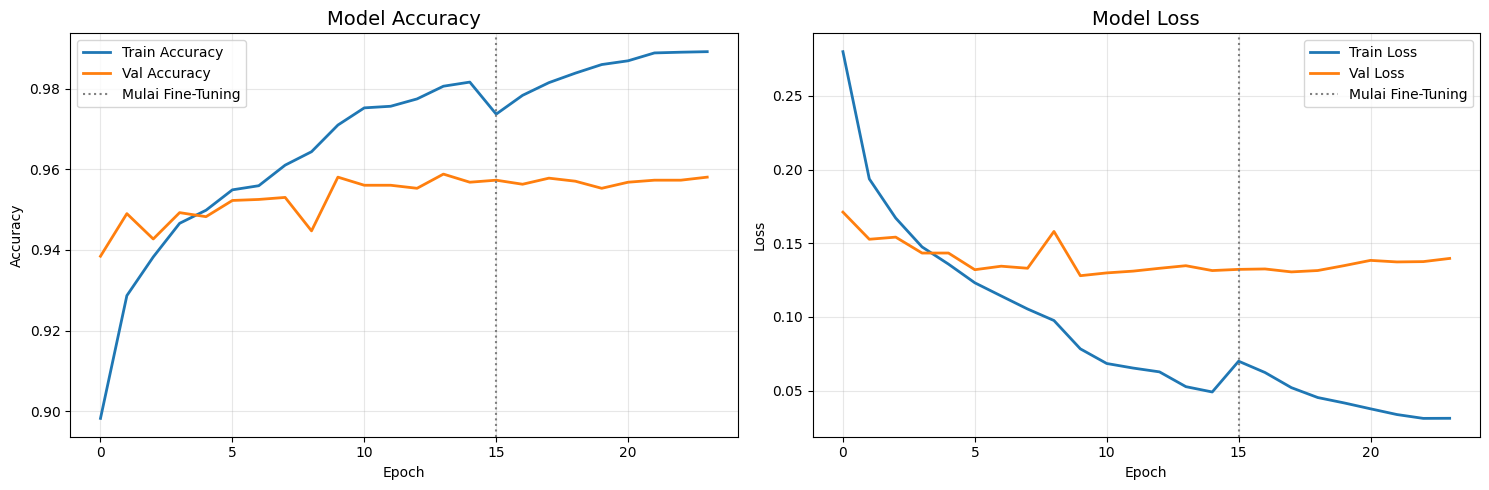

In [ ]:
# Plot Kurva Training Gabungan

acc_all = history_head.history['accuracy'] + history_finetune.history['accuracy']
val_acc_all = history_head.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss_all = history_head.history['loss'] + history_finetune.history['loss']
val_loss_all = history_head.history['val_loss'] + history_finetune.history['val_loss']
switch_epoch = len(history_head.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(acc_all, label='Train Accuracy', linewidth=2)
ax1.plot(val_acc_all, label='Val Accuracy', linewidth=2)
ax1.axvline(x=switch_epoch, color='gray', linestyle=':', label='Mulai Fine-Tuning')
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(loss_all, label='Train Loss', linewidth=2)
ax2.plot(val_loss_all, label='Val Loss', linewidth=2)
ax2.axvline(x=switch_epoch, color='gray', linestyle=':', label='Mulai Fine-Tuning')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Backup ke Google Drive
curve_path = os.path.join(CKPT_DIR, 'training_history.png')
plt.savefig(curve_path, dpi=200, bbox_inches='tight')
print('Grafik kurva training tersimpan di Drive:', curve_path)

plt.show()


## 13. Prediksi pada Data Test & Visualisasi Contoh
Memprediksi seluruh gambar pada folder `test/` (tanpa label), lalu menampilkan beberapa contoh hasil prediksi berikut tingkat keyakinannya (confidence).

In [ ]:
# Prediksi Seluruh Data Test

test_files = sorted(os.listdir(LOCAL_TEST))
print(f"Total gambar test: {len(test_files)}")

def load_and_agbf_for_predict(img_path, target_size=IMG_SIZE):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (target_size, target_size))
    img = agbf_filter(img)
    img = img.astype(np.float32)
    img = preprocess_input(img)
    return img

# Prediksi per-batch supaya hemat memori
test_results = []
BATCH_PRED = 64
batch_imgs, batch_names = [], []

for i, fname in enumerate(test_files):
    fpath = os.path.join(LOCAL_TEST, fname)
    batch_imgs.append(load_and_agbf_for_predict(fpath))
    batch_names.append(fname)

    if len(batch_imgs) == BATCH_PRED or i == len(test_files) - 1:
        arr = np.stack(batch_imgs, axis=0)
        preds = best_model.predict(arr, verbose=0)
        for name, p in zip(batch_names, preds):
            idx = int(np.argmax(p))
            test_results.append({
                'file': name,
                'pred_idx': idx,
                'pred_class': CLASS_NAMES[idx],
                'pred_label': DISPLAY_NAMES[idx],
                'confidence(%)': float(np.max(p) * 100),
            })
        batch_imgs, batch_names = [], []

    if (i + 1) % 1000 == 0:
        print(f"  ... {i+1}/{len(test_files)} gambar diprediksi")

df_test_results = pd.DataFrame(test_results)

# Backup hasil prediksi test ke Google Drive
pred_path = os.path.join(CKPT_DIR, 'prediksi_test.csv')
df_test_results.to_csv(pred_path, index=False)
print('Hasil prediksi test tersimpan di Drive:', pred_path)

df_test_results.head()


Total gambar test: 1458
  ... 1000/1458 gambar diprediksi
Hasil prediksi test tersimpan di Drive: /content/drive/MyDrive/BDC2026_2/checkpoints/prediksi_test.csv


,file,pred_idx,pred_class,pred_label,confidence(%)
0,1.jpg,2,2_Organic,Organic,99.996841
1,10.jpg,2,2_Organic,Organic,99.994827
2,100.jpg,0,0_Recyclable,Recyclable,99.986717
3,1000.jpg,2,2_Organic,Organic,99.995102
4,1001.jpg,0,0_Recyclable,Recyclable,99.802895


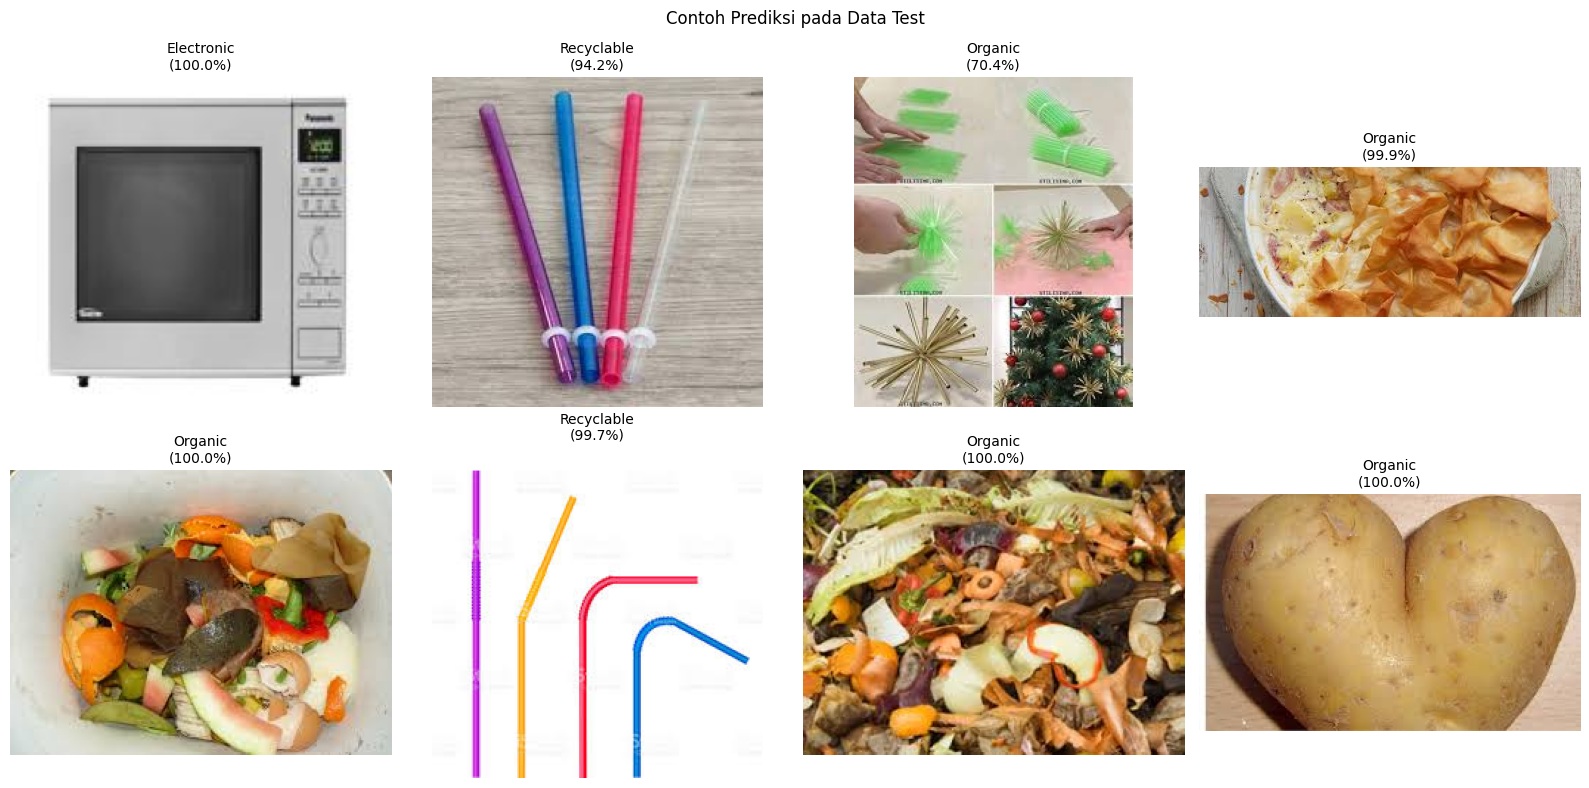

In [ ]:
# Visualisasi Beberapa Contoh Prediksi

n_show = 8
sample_rows = df_test_results.sample(n_show, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, n_show // 2, figsize=(4 * n_show // 2, 8))
axes = axes.flatten()

for i, row in sample_rows.iterrows():
    img_path = os.path.join(LOCAL_TEST, row['file'])
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"{row['pred_label']}\n({row['confidence(%)']:.1f}%)", fontsize=10)

plt.suptitle('Contoh Prediksi pada Data Test')
plt.tight_layout()
plt.show()


In [ ]:
# Bangun submission_NamaTim.csv

sub_template = pd.read_csv(os.path.join(DATASET_ROOT, 'submission.csv'))
print('Baris di template:', len(sub_template))

test_files_by_stem = {os.path.splitext(f)[0]: f for f in os.listdir(LOCAL_TEST)}

ordered_preds = []
for _id in sub_template['id']:
    stem = str(_id)
    if stem not in test_files_by_stem:
        raise FileNotFoundError(f'Tidak ditemukan file test untuk id={_id}')
    fname = test_files_by_stem[stem]
    row = df_test_results.loc[df_test_results['file'] == fname, 'pred_idx']
    ordered_preds.append(int(row.values[0]))

assert len(ordered_preds) == len(sub_template)

TEAM_NAME = 'SD2026040000623'
submission = sub_template.copy()
submission['predicted'] = ordered_preds

# Simpan ke folder milik sendiri
out_path = os.path.join(OUTPUT_ROOT, f'submission_{TEAM_NAME}.csv')
submission.to_csv(out_path, index=False)
print('Submission tersimpan:', out_path)
submission.head()

Baris di template: 1458
Submission tersimpan: /content/drive/MyDrive/BDC2026_2/submission_SD2026040000623.csv


,id,predicted
0,1,2
1,2,2
2,3,2
3,4,1
4,5,0


## 14. Simpan Model Final & Ringkasan Metrik

In [ ]:
# Simpan Model Final & Ringkasan Metrik ke Drive

final_model_path = os.path.join(CKPT_DIR, 'model_final_resnet50_agbf.keras')
best_model.save(final_model_path)
print("Model final tersimpan di:", final_model_path)

metrics_summary = pd.DataFrame([{
    'Model': 'ResNet50 + AGBF + Fine-Tuning (Full Dataset)',
    'Val Accuracy': acc,
    'Val Precision': prec,
    'Val Recall': rec,
    'Val F1-Score': f1,
    'Training Time Fase 1 (s)': train_time_head,
    'Training Time Fase 2 (s)': train_time_finetune,
}])
metrics_summary.to_csv(os.path.join(CKPT_DIR, 'ringkasan_metrik.csv'), index=False)
print("\nRingkasan metrik akhir:")
print(metrics_summary.to_string(index=False))


Model final tersimpan di: /content/drive/MyDrive/BDC2026_2/checkpoints/model_final_resnet50_agbf.keras

Ringkasan metrik akhir:
                                       Model  Val Accuracy  Val Precision  Val Recall  Val F1-Score  Training Time Fase 1 (s)  Training Time Fase 2 (s)
ResNet50 + AGBF + Fine-Tuning (Full Dataset)      0.957789       0.957828    0.957789      0.957794               1562.739961                719.868567


## 15. Kesimpulan


> Penelitian ini telah menerapkan metode Adaptive Gaussian Bilateral Filter (AGBF) pada tahap praproses citra dan menggunakan arsitektur ResNet50 dengan proses fine-tuning untuk melakukan klasifikasi citra sampah ke dalam tiga kategori, yaitu Recyclable, Electronic, dan Organic. Dataset yang digunakan terdiri dari 26.527 data latih dan 1.458 data uji, dengan proses pelatihan dilakukan melalui dua tahap, yaitu pelatihan classifier head (feature extraction) dan fine-tuning pada sebagian layer ResNet50 untuk meningkatkan kemampuan model dalam mengenali karakteristik citra. Model kemudian dilatih menggunakan dataset yang tersedia dan dievaluasi menggunakan data validasi untuk mengetahui kinerja klasifikasinya.

> Berdasarkan hasil pengujian pada data validasi, model memperoleh accuracy, precision, recall, dan F1-score sebesar 95,78%. Namun, hasil tersebut diperoleh berdasarkan dataset dan skenario pengujian dalam penelitian ini sehingga performa model pada dataset atau kondisi yang berbeda masih perlu dievaluasi lebih lanjut.

> Oleh karena itu, pengujian menggunakan dataset yang lebih beragam serta pengembangan metode praproses atau arsitektur model dapat dilakukan pada penelitian selanjutnya untuk memperoleh gambaran performa yang lebih komprehensif.


